In [4]:
from dieslog import DiesLog
import numpy as np
import matplotlib.pyplot as plt

logfile = '../logs/dies-2026-06-21_13-52-56'
l = DiesLog(logfile)

<Axes: xlabel='t [s]', ylabel='speed [mm/s]'>

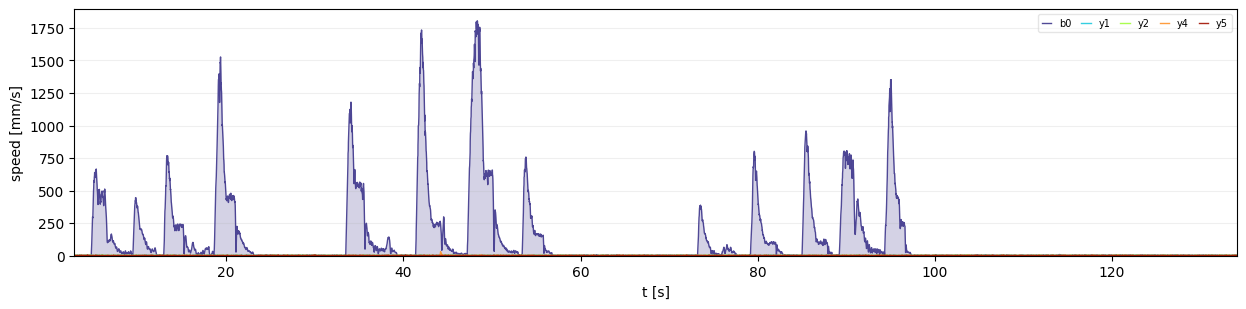

In [5]:
l.timeline()

In [7]:
l.robots()

[('blue', 0), ('yellow', 1), ('yellow', 2), ('yellow', 4), ('yellow', 5)]

<Figure size 1500x320 with 0 Axes>

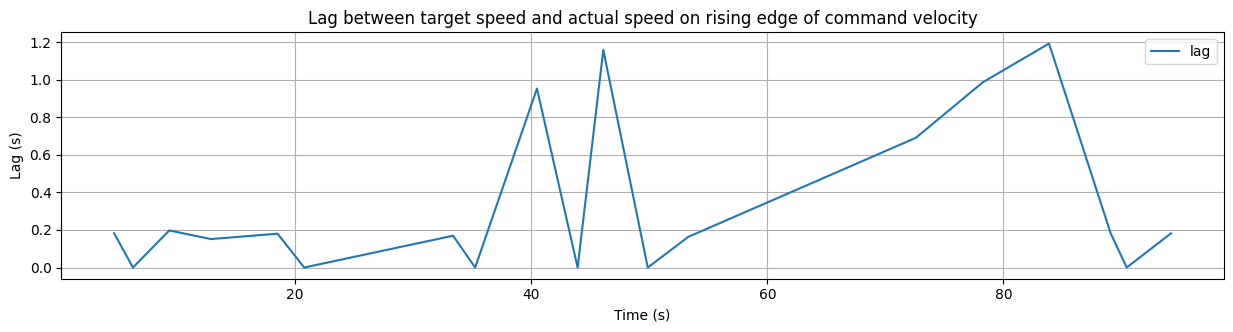

In [14]:
r0 = l.robot('blue', 0)
plt.figure(figsize=(15, 3.2))

# plt.plot(r0.index, np.hypot(r0.vx, r0.vy), label='speed')
# plt.plot(r0.index, np.hypot(r0.target_vel_x, r0.target_vel_y), label='target speed')
# plt.legend()
# plt.title('Robot 0 speed vs target speed')
# plt.xlabel('Time (s)')
# plt.ylabel('Speed (mm/s)')
# plt.grid()
# plt.show()

target_speed_threshold = 100
target_speed = np.hypot(
    r0.target_vel_x.to_numpy(dtype=float),
    r0.target_vel_y.to_numpy(dtype=float),
)
actual_speed = np.hypot(r0.vx.to_numpy(), r0.vy.to_numpy())
times = r0.index.to_numpy()

events = []
for i in range(1, len(target_speed)):
    if target_speed[i - 1] < target_speed_threshold and target_speed[i] >= target_speed_threshold:
        events.append(i)

lags = []
for event in events:
    post = actual_speed[event:]
    if not np.any(post >= target_speed_threshold):
        continue
    idx = np.argmax(post >= target_speed_threshold)
    lag = times[event + idx] - times[event]
    lags.append(lag)

plt.figure(figsize=(15, 3.2))
plt.plot(times[events[:len(lags)]], lags, label='lag')
plt.legend()
plt.title('Lag between target speed and actual speed on rising edge of command velocity')
plt.xlabel('Time (s)')
plt.ylabel('Lag (s)')
plt.grid()

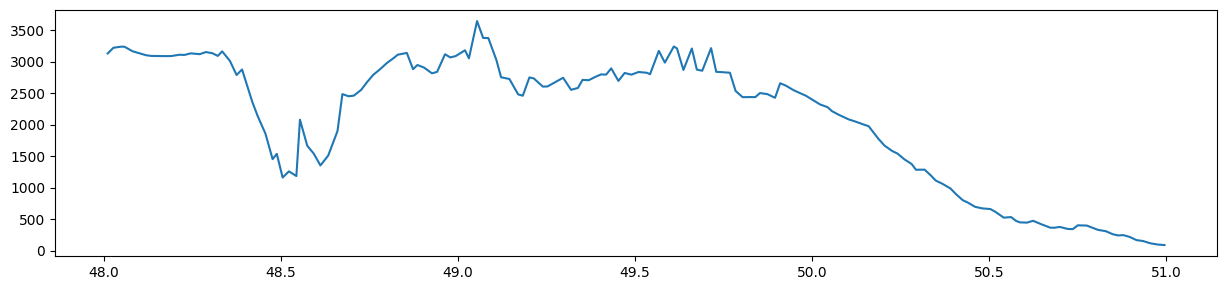

In [21]:
from dieslog import load
import numpy as np, matplotlib.pyplot as plt

log = load('../logs/dies-2026-06-21_14-07-23.dieslog')
r = log.robot('blue', 0).loc[48:51].copy()



# plt.scatter(r.x, r.y, c=r.index, cmap='viridis', label='R0')
# plt.colorbar(label='Time (s)')

# # draw heading (yaw) as lines for each point
# for i in range(len(r)):
#     x, y, yaw = r.x.iloc[i], r.y.iloc[i], r["raw_yaw"].iloc[i]
#     dx = 20 * np.cos(yaw)
#     dy = 20 * np.sin(yaw)
#     plt.arrow(x, y, dx, dy, head_width=10, head_length=30, fc='red', ec='red')
    
cmd_vel = np.stack((r.target_vel_x, r.target_vel_y), axis=1)
real_vel = np.stack((r.vx, r.vy), axis=1)
vel_error = np.linalg.norm(cmd_vel - real_vel, axis=1)

plt.figure(figsize=(15, 3.2))
plt.plot(r.index, vel_error, label='velocity error')